In [2]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.7 MB/s eta 0:00:00


In [3]:
#importing necessary libraries
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
import seaborn as sns
import plotly.graph_objects as go

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU, Input

from tensorflow.keras.callbacks import EarlyStopping

In [4]:
#Loading the Dataset
df = pd.read_csv("Stock_Price_Data_[3921].csv")

In [ ]:
#Checking the first five rows
print(df.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400


In [ ]:
#Checking the shape of the Dataset
print(df.shape)

(9909, 7)


In [ ]:
# Display concise summary of dataframe structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB
None


In [ ]:
#Display Statistical Summary
print(df.describe())

              Open         High          Low        Close    Adj Close  \
count  9909.000000  9909.000000  9909.000000  9909.000000  9909.000000   
mean     32.606849    32.936079    32.277560    32.618030    30.576570   
std      58.415759    59.001576    57.883037    58.471899    56.746275   
min       0.198661     0.198661     0.196429     0.196429     0.155638   
25%       1.071429     1.089286     1.048571     1.071429     0.917643   
50%       1.729286     1.758929     1.696429     1.732143     1.466154   
75%      35.799999    36.265713    35.328571    35.761429    31.042374   
max     324.739990   327.850006   323.350006   327.200012   327.200012   

             Volume  
count  9.909000e+03  
mean   8.582916e+07  
std    8.597195e+07  
min    3.472000e+05  
25%    3.304230e+07  
50%    5.766490e+07  
75%    1.069992e+08  
max    1.855410e+09  


In [ ]:
#Checking the Datatypes of each column
print(df.dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [ ]:
#Checking if there are any null values
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [ ]:
#Checking for duplicates
print(df.duplicated().sum())

0


In [7]:
#Converting Date column into datatime type
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
# Set 'Date' column as the index to enable time-series operations
df.set_index("Date", inplace=True)

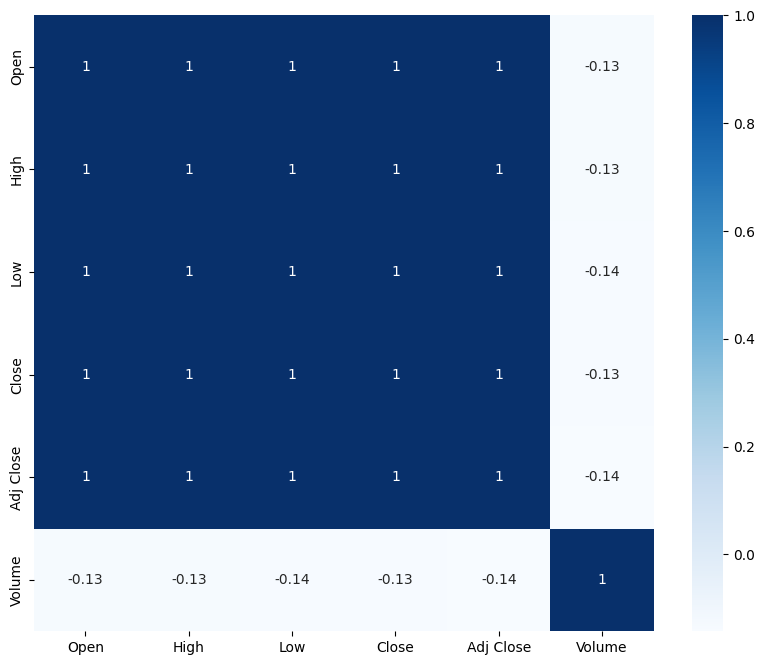

In [ ]:
#Checking for the correlation between the columns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
# Save the figure as an image file before showing
plt.savefig("correlation.png", dpi=1000, bbox_inches="tight")
plt.show()

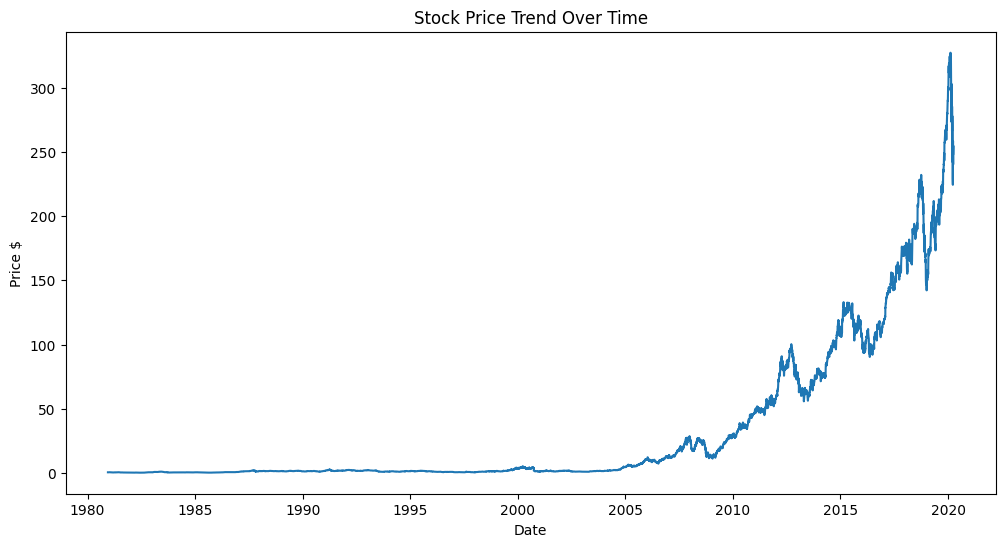

In [ ]:
#Created a line chart to see the Trend
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Stock Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price $")
# Save the figure as an image file before showing
plt.savefig("stock price trend.png", dpi=1000, bbox_inches="tight")
plt.show()

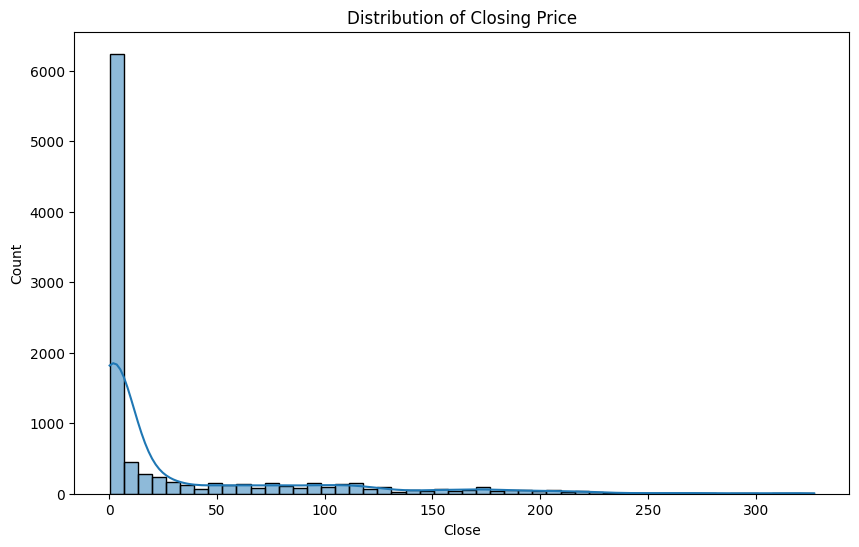

In [6]:
# Distribution of Closing Price

plt.figure(figsize=(10,6))

sns.histplot(df['Close'],
             bins=50,
             kde=True)

plt.title("Distribution of Closing Price")
plt.savefig('Distribution of Closing Price.png',
            dpi=1080,
            bbox_inches='tight')

plt.savefig("distribution of closing price.png", dpi=1000, bbox_inches="tight")
plt.show()

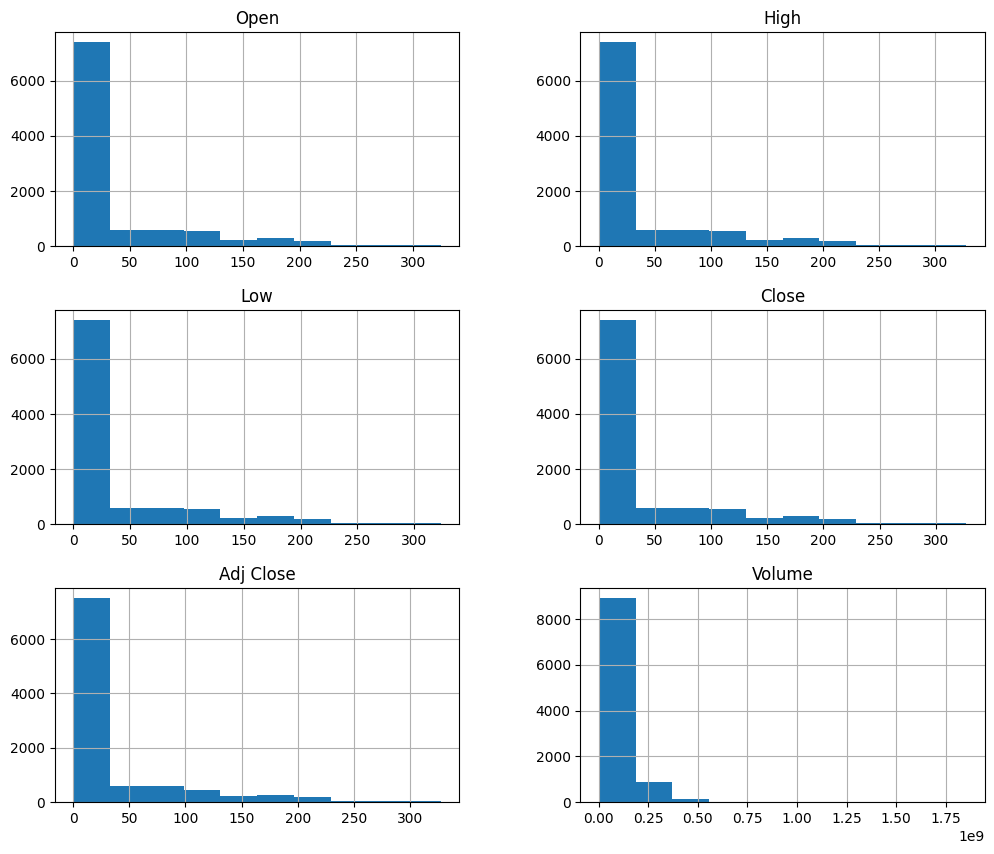

In [ ]:
#Created Histogram
df.hist(figsize=(12,10))

# Save the figure as an image file before showing
plt.savefig("histogram.png", dpi=1000, bbox_inches="tight")
plt.show()

In [ ]:
# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Starting date
start = df.index.min()

# Define 10-year ranges
df_1 = df.loc[start : start + pd.DateOffset(years=10)]
df_2 = df.loc[start + pd.DateOffset(years=10) : start + pd.DateOffset(years=20)]
df_3 = df.loc[start + pd.DateOffset(years=20) : start + pd.DateOffset(years=30)]

# ---------------- 1st Decade ----------------
fig1 = go.Figure(data=[go.Candlestick(
    x=df_1.index,
    open=df_1['Open'],
    high=df_1['High'],
    low=df_1['Low'],
    close=df_1['Close'],
    name='Price'
)])

fig1.update_layout(
    title="Candlestick Chart (Decade 1: 0–10 Years)",
    xaxis_title="Date",
    yaxis_title="Stock Price",
    xaxis_rangeslider_visible=False,
    xaxis=dict(showticklabels=True),
    yaxis=dict(showticklabels=True)
)

fig1.show()

# ---------------- 2nd Decade ----------------
fig2 = go.Figure(data=[go.Candlestick(
    x=df_2.index,
    open=df_2['Open'],
    high=df_2['High'],
    low=df_2['Low'],
    close=df_2['Close'],
    name='Price'
)])

fig2.update_layout(
    title="Candlestick Chart (Decade 2: 10–20 Years)",
    xaxis_title="Date",
    yaxis_title="Stock Price",
    xaxis_rangeslider_visible=False,
    xaxis=dict(showticklabels=True),
    yaxis=dict(showticklabels=True)
)

fig2.show()

# ---------------- 3rd Decade ----------------
fig3 = go.Figure(data=[go.Candlestick(
    x=df_3.index,
    open=df_3['Open'],
    high=df_3['High'],
    low=df_3['Low'],
    close=df_3['Close'],
    name='Price'
)])

fig3.update_layout(
    title="Candlestick Chart (Decade 3: 20–30 Years)",
    xaxis_title="Date",
    yaxis_title="Stock Price",
    xaxis_rangeslider_visible=False,
    xaxis=dict(showticklabels=True),
    yaxis=dict(showticklabels=True)
)

fig3.show()

In [ ]:
# Loop through each column in the dataframe to detect outliers using IQR method
for column in df.columns:

    # Calculate first quartile (25th percentile)
    Q1 = df[column].quantile(0.25)

    # Calculate third quartile (75th percentile)
    Q3 = df[column].quantile(0.75)

    # Compute Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Define lower bound for outliers
    lower = Q1 - 1.5 * IQR

    # Define upper bound for outliers
    upper = Q3 + 1.5 * IQR

    # Filter rows that are considered outliers
    outliers = df[(df[column] < lower) | (df[column] > upper)]

    # Print number of outliers for each column
    print(f"{column}: {len(outliers)} outliers")

Open: 1543 outliers
High: 1537 outliers
Low: 1540 outliers
Close: 1539 outliers
Adj Close: 1558 outliers
Volume: 705 outliers


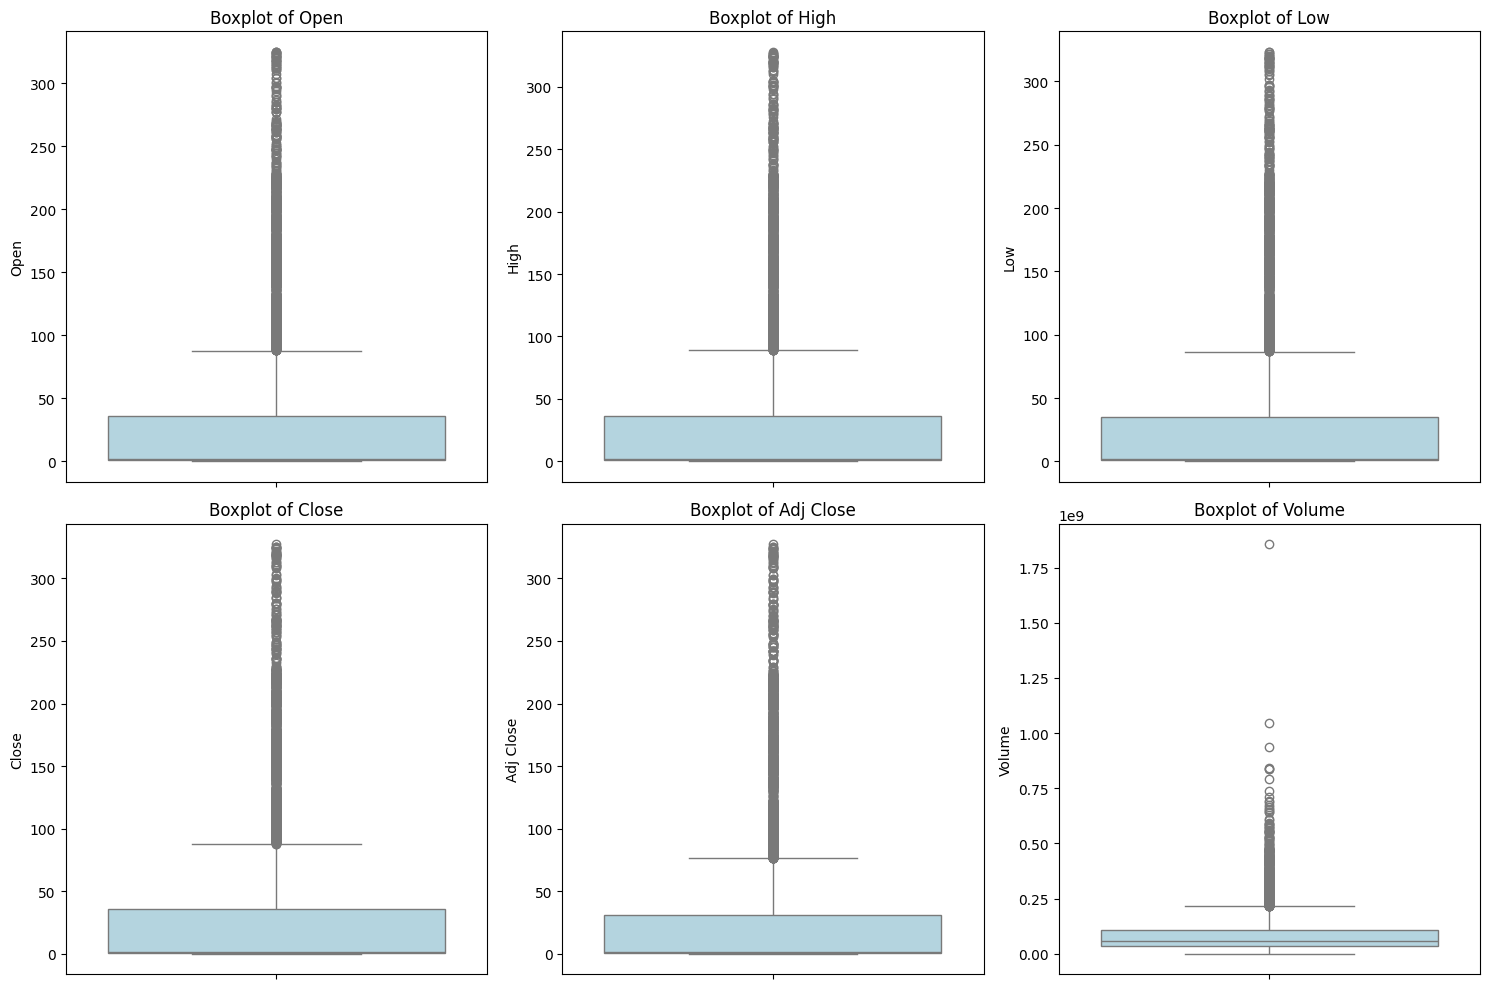

In [ ]:
# Select only numerical columns (int and float types)
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Create a figure with specified size for better visualization
plt.figure(figsize=(15, 10))

# Loop through each numerical column and create boxplots
for i, column in enumerate(numeric_columns, 1):

    # Create subplot in a 2x3 grid
    plt.subplot(2, 3, i)

    # Draw boxplot for each numerical feature to visualize distribution and outliers
    sns.boxplot(y=df[column], color='lightblue')

    # Set title for each subplot
    plt.title(f'Boxplot of {column}')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Save the figure as an image file before showing
plt.savefig("boxplots.png", dpi=1000, bbox_inches="tight")

# Display the plots
plt.show()

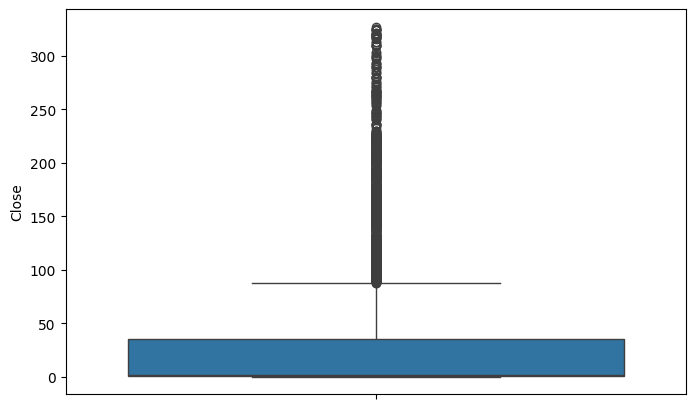

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(df["Close"])
# Save the figure as an image file before showing
plt.savefig("boxplots_of_close.png", dpi=1000, bbox_inches="tight")
plt.show()

In [12]:
#Selecting Close column from the Dataset
data = df[["Close"]]

In [13]:
# Initialize MinMaxScaler to scale all values between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))

# Fit the scaler on the data and transform it
scaled_data = scaler.fit_transform(data)

In [14]:
# Define the number of time steps to look back (sequence length)
sequence_length = 60

# Initialize lists to store input sequences (X) and target values (y)
X = []
y = []

# Create sequences for time-series forecasting
for i in range(sequence_length, len(scaled_data)):

    # Take previous 'sequence_length' values as input
    X.append(scaled_data[i-sequence_length:i, 0])

    # Take the current value as output/target
    y.append(scaled_data[i, 0])

# Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)


In [15]:
# Reshape X to 3D format required for LSTM/GRU: (samples, time_steps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [16]:
# Split dataset into training (70%) and testing (20%) sets

# Compute index for 70% of the dataset
train_size = int(len(X) * 0.7)

# Compute index for 20% test set
test_size = int(len(X) * 0.2)

# Training input data (first 70%)
X_train = X[:train_size]
y_train = y[:train_size]

# Testing input data (next 20%)
X_test = X[train_size:train_size + test_size]
y_test = y[train_size:train_size + test_size]

#Remaining 10% can be used as validation
X_val = X[train_size + test_size:]
y_val = y[train_size + test_size:]

In [17]:
# Early stopping to prevent overfitting and stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',          # monitor validation loss
    patience=10,                 # wait 10 epochs before stopping if no improvement
    restore_best_weights=True    # restore best model weights after stopping
)

In [ ]:
# Define LSTM model architecture
lstm_model = Sequential([

    # First LSTM layer with 64 units, returning sequences for next LSTM layer
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),

    # Dropout layer to reduce overfitting
    Dropout(0.2),

    # Second LSTM layer
    LSTM(64),

    # Dropout layer
    Dropout(0.2),

    # Output layer (single prediction value)
    Dense(1)
])

# Compile model using Adam optimizer and Mean Squared Error loss function
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train the LSTM model
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),   # 10% of training data used for validation
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



216/216 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - loss: 1.3713e-05 - val_loss: 0.0020
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - loss: 4.5560e-06 - val_loss: 4.8833e-04
Epoch 3/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 4.1617e-06 - val_loss: 0.0012
Epoch 4/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - loss: 3.2166e-06 - val_loss: 0.0027
Epoch 5/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - loss: 3.3727e-06 - val_loss: 4.2618e-04
Epoch 6/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 3.3029e-06 - val_loss: 0.0016
Epoch 7/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 3.3846e-06 - val_loss: 0.0041
Epoch 8/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - loss: 3.6456e-06 - val_loss: 4.5453e-04
Epoch 9/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 3.1868e-06 - val_loss: 5.3096e-04
Epoch 10/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 3.0460e-06 - val_loss: 4.7773e-04
Epoch 11/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 2.7406e

In [ ]:
# Make predictions using trained LSTM model on test data
lstm_predictions = lstm_model.predict(X_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


In [ ]:
lstm_predictions = scaler.inverse_transform(lstm_predictions)

actual = scaler.inverse_transform(y_test.reshape(-1,1))

In [ ]:
# Calculate Mean Absolute Error between actual and predicted values
mae_lstm = mean_absolute_error(actual, lstm_predictions)

# Calculate Mean Squared Error
mse_lstm = mean_squared_error(actual, lstm_predictions)

# Calculate Root Mean Squared Error
rmse_lstm = np.sqrt(mse_lstm)

# Calculate R-squared score (goodness of fit)
r2_lstm = r2_score(actual, lstm_predictions)

# Print evaluation metrics for LSTM model
print("LSTM MAE :", mae_lstm)
print("LSTM MSE :", mse_lstm)
print("LSTM RMSE :", rmse_lstm)
print("LSTM R2 :", r2_lstm)

LSTM MAE : 2.7808349884482673
LSTM MSE : 12.461862194020942
LSTM RMSE : 3.5301362854741094
LSTM R2 : 0.9891121331672681


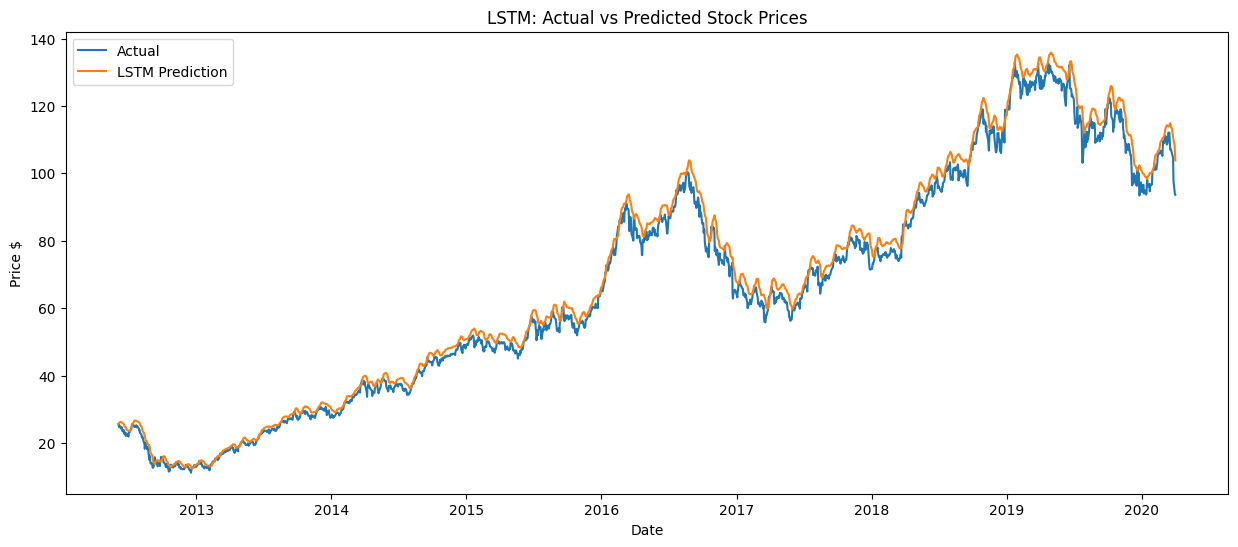

In [ ]:
# Create a line chart to compare actual and predicted stock prices
plt.figure(figsize=(15,6))

# Plot actual stock prices
plt.plot(df.index[-len(actual):], actual, label="Actual")

# Plot LSTM predicted stock prices
plt.plot(df.index[-len(lstm_predictions):], lstm_predictions, label="LSTM Prediction")

# Add chart title and axis labels
plt.title("LSTM: Actual vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price $")

# Display legend
plt.legend()

# Save the figure before showing
plt.savefig("lstm_prediction_plot.png", dpi=1000, bbox_inches="tight")

# Display the plot
plt.show()

In [ ]:
# Define GRU model architecture for time-series forecasting
gru_model = Sequential([

    # First GRU layer with 64 units, returning sequences for next GRU layer
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),

    # Dropout layer to reduce overfitting
    Dropout(0.2),

    # Second GRU layer
    GRU(64),

    # Dropout layer
    Dropout(0.2),

    # Output layer for final prediction
    Dense(1)
])

# Compile the model using Adam optimizer and MSE loss function
gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train the GRU model
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),   # 10% validation split
    epochs=50,
    batch_size=32,
    callbacks=[early_stop], # Early stopping to avoid overfitting
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



216/216 ━━━━━━━━━━━━━━━━━━━━ 22s 82ms/step - loss: 1.8343e-05 - val_loss: 0.0024
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - loss: 3.8092e-06 - val_loss: 0.0035
Epoch 3/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - loss: 3.8112e-06 - val_loss: 0.0022
Epoch 4/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - loss: 3.9700e-06 - val_loss: 5.5333e-04
Epoch 5/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - loss: 3.6903e-06 - val_loss: 0.0011
Epoch 6/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - loss: 3.3122e-06 - val_loss: 0.0023
Epoch 7/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - loss: 3.5588e-06 - val_loss: 3.8825e-04
Epoch 8/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - loss: 3.3596e-06 - val_loss: 3.0088e-04
Epoch 9/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - loss: 3.3533e-06 - val_loss: 4.6147e-04
Epoch 10/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - loss: 3.5146e-06 - val_loss: 3.7247e-04
Epoch 11/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - loss: 2.8054e

In [ ]:
# Make predictions using trained GRU model on test data
gru_predictions = gru_model.predict(X_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


In [ ]:
# Convert predictions back to original scale using inverse transform
gru_predictions = scaler.inverse_transform(gru_predictions)

In [ ]:
# Calculate Mean Absolute Error between actual and predicted values
mae_gru = mean_absolute_error(actual, gru_predictions)

# Calculate Mean Squared Error
mse_gru = mean_squared_error(actual, gru_predictions)

# Calculate Root Mean Squared Error
rmse_gru = np.sqrt(mse_gru)

# Calculate R-squared score
r2_gru = r2_score(actual, gru_predictions)

# Print evaluation metrics for GRU model
print("GRU MAE :", mae_gru)
print("GRU MSE :", mse_gru)
print("GRU RMSE :", rmse_gru)
print("GRU R2 :", r2_gru)

GRU MAE : 1.112735225683302
GRU MSE : 2.545409879556163
GRU RMSE : 1.595434072456823
GRU R2 : 0.9977760880860467


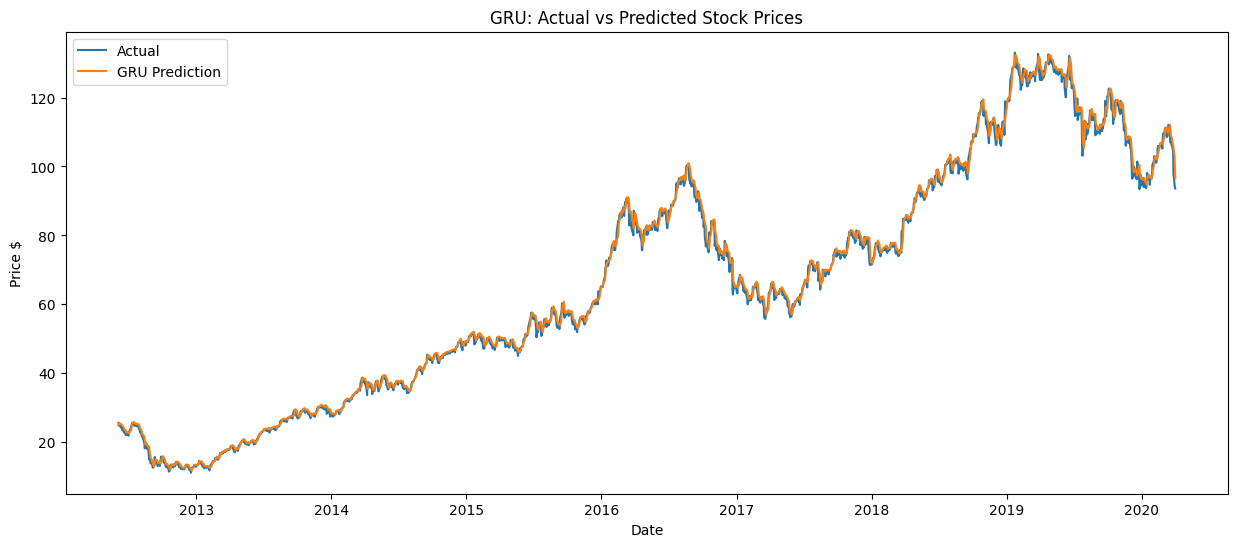

In [ ]:
# Create a line chart to compare actual and predicted stock prices
plt.figure(figsize=(15,6))

# Plot actual stock prices
plt.plot(df.index[-len(actual):], actual, label="Actual")

# Plot GRU predicted stock prices
plt.plot(df.index[-len(gru_predictions):], gru_predictions, label="GRU Prediction")

# Add chart title and axis labels
plt.title("GRU: Actual vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price $")

# Display legend
plt.legend()

# Save the figure before showing
plt.savefig("gru_prediction_plot.png", dpi=1000, bbox_inches="tight")

# Display the plot
plt.show()

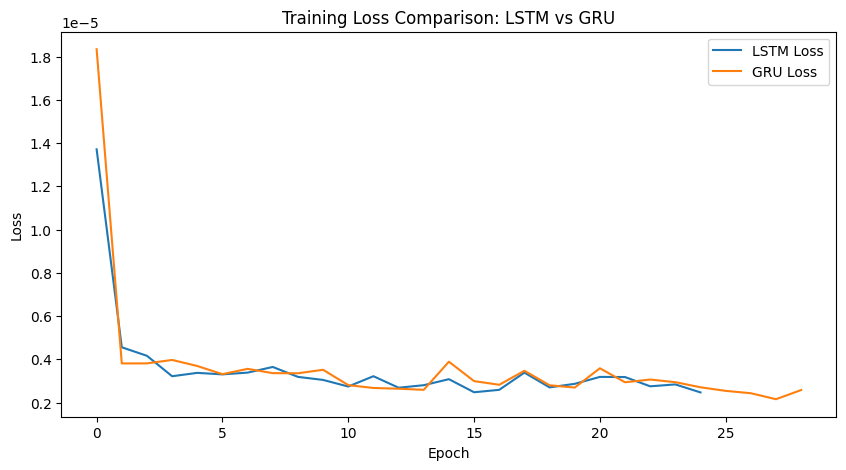

In [ ]:
# Plot training loss comparison between LSTM and GRU models
plt.figure(figsize=(10,5))

# LSTM training loss curve
plt.plot(history_lstm.history['loss'], label='LSTM Loss')

# GRU training loss curve
plt.plot(history_gru.history['loss'], label='GRU Loss')

# Add chart title and axis labels
plt.title("Training Loss Comparison: LSTM vs GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Add legend
plt.legend()

# Save the figure before displaying
plt.savefig("lstm_gru_training_loss.png", dpi=1000, bbox_inches="tight")

# Display plot
plt.show()

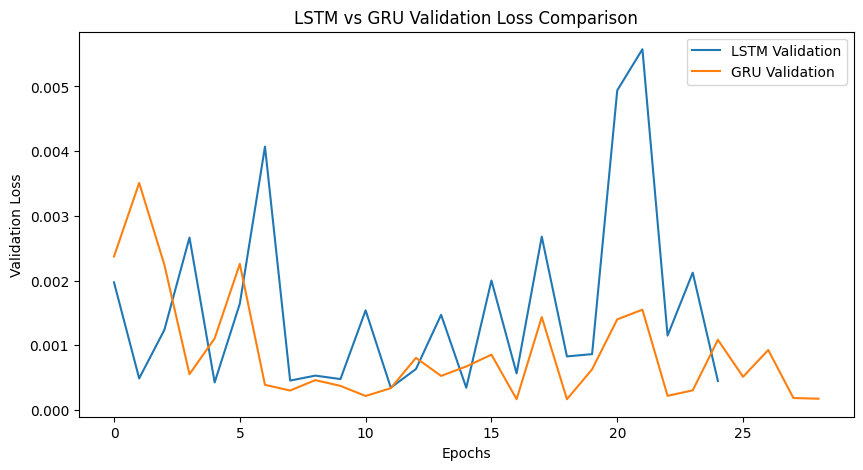

In [ ]:
# Plot validation loss comparison between LSTM and GRU models
plt.figure(figsize=(10,5))

# LSTM validation loss curve
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation')

# GRU validation loss curve
plt.plot(history_gru.history['val_loss'], label='GRU Validation')

# Labels and title
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('LSTM vs GRU Validation Loss Comparison')

# Legend
plt.legend()

# Save figure
plt.savefig('lstm_gru_validation_loss.png', dpi=300, bbox_inches='tight')

# Show plot
plt.show()

In [ ]:
# Create a comparison dataframe for LSTM vs GRU performance metrics
comparison = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MAE": [mae_lstm, mae_gru],
    "MSE": [mse_lstm, mse_gru],
    "RMSE": [rmse_lstm, rmse_gru],
    "R2 Score": [r2_lstm, r2_gru]
})

# Print comparison table
print(comparison)

  Model       MAE        MSE      RMSE  R2 Score
0  LSTM  2.780835  12.461862  3.530136  0.989112
1   GRU  1.112735   2.545410  1.595434  0.997776


In [ ]:
# Fix sequence length once for reproducibility and speed
SEQ = 60

# Create sequences for LSTM input
X, y = [], []
for i in range(SEQ, len(scaled_data)):
    X.append(scaled_data[i-SEQ:i, 0])
    y.append(scaled_data[i, 0])

# Convert to numpy arrays and reshape for LSTM (samples, timesteps, features)
X = np.array(X).reshape(-1, SEQ, 1)
y = np.array(y)

# Objective function for Optuna hyperparameter tuning
def objective(trial):

    # Hyperparameter search space
    units = trial.suggest_categorical("units", [32, 64, 128])
    dropout = trial.suggest_categorical("dropout", [0.2, 0.3, 0.5])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    epochs = trial.suggest_int("epochs", 20, 40)

    # Define LSTM model
    model = Sequential()
    model.add(Input(shape=(SEQ, 1)))

    model.add(LSTM(units, return_sequences=True))
    model.add(Dropout(dropout))

    model.add(LSTM(units))
    model.add(Dropout(dropout))

    model.add(Dense(1))

    # Compile model
    model.compile(optimizer='adam', loss='mse')

    # Early stopping to avoid overfitting
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Train model
    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stop]
    )

    # Predict on test set
    preds = model.predict(X_test, verbose=0)

    # Compute MSE for optimization objective
    mse = mean_squared_error(y_test, preds)

    return mse


# Create Optuna study to minimize MSE
study = optuna.create_study(direction="minimize")

# Run hyperparameter optimization
study.optimize(objective, n_trials=20)

# Print best parameters and score
print("Best Params:", study.best_params)
print("Best MSE:", study.best_value)


[I 2026-07-07 18:07:13,650] A new study created in memory with name: no-name-aacf9fd0-8a72-449b-ba81-9102ed4f3698
[I 2026-07-07 18:08:23,158] Trial 0 finished with value: 6.7805007505168e-05 and parameters: {'units': 64, 'dropout': 0.2, 'batch_size': 64, 'epochs': 38}. Best is trial 0 with value: 6.7805007505168e-05.
[I 2026-07-07 18:10:15,427] Trial 1 finished with value: 6.513410209632967e-05 and parameters: {'units': 64, 'dropout': 0.5, 'batch_size': 16, 'epochs': 28}. Best is trial 1 with value: 6.513410209632967e-05.
[I 2026-07-07 18:11:13,839] Trial 2 finished with value: 0.00011450297023877143 and parameters: {'units': 64, 'dropout': 0.3, 'batch_size': 64, 'epochs': 23}. Best is trial 1 with value: 6.513410209632967e-05.
[I 2026-07-07 18:14:25,652] Trial 3 finished with value: 5.352660754699536e-05 and parameters: {'units': 64, 'dropout': 0.5, 'batch_size': 16, 'epochs': 39}. Best is trial 3 with value: 5.352660754699536e-05.
[I 2026-07-07 18:17:34,105] Trial 4 finished with val

Best Params: {'units': 128, 'dropout': 0.3, 'batch_size': 32, 'epochs': 36}
Best MSE: 4.543445095216353e-05


In [9]:
# Best hyperparameters (from Optuna)
units = 128
dropout = 0.3
batch_size = 32
epochs = 36
SEQ = 60


In [24]:
# Define final LSTM model with best parameters
lstm_model = Sequential([
    Input(shape=(SEQ, 1)),

    LSTM(units, return_sequences=True),
    Dropout(dropout),

    LSTM(units),
    Dropout(dropout),

    Dense(1)
])

# Compile model
lstm_model.compile(optimizer='adam', loss='mse')

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train final model
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)
# Make predictions
lstm_pred = lstm_model.predict(X_test)

# Evaluate model performance
lstm_mse = mean_squared_error(y_test, lstm_pred)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_r2 = r2_score(y_test, lstm_pred)

# Print results
print("LSTM RESULTS")
print("MSE :", lstm_mse)
print("RMSE:", lstm_rmse)
print("MAE :", lstm_mae)
print("R2  :", lstm_r2)

Epoch 1/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - loss: 1.8015e-05 - val_loss: 7.9825e-04
Epoch 2/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 39s 180ms/step - loss: 3.7793e-06 - val_loss: 5.2658e-04
Epoch 3/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 38s 175ms/step - loss: 4.7255e-06 - val_loss: 0.0013
Epoch 4/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 37s 170ms/step - loss: 4.4696e-06 - val_loss: 3.5254e-04
Epoch 5/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 42s 173ms/step - loss: 4.2890e-06 - val_loss: 6.2103e-04
Epoch 6/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 37s 171ms/step - loss: 4.0972e-06 - val_loss: 0.0017
Epoch 7/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 38s 177ms/step - loss: 3.8201e-06 - val_loss: 0.0013
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step
LSTM RESULTS
MSE : 4.3619038062013e-05
RMSE: 0.006604471066028906
MAE : 0.004879216879854809
R2  : 0.9959248747251775


In [26]:
# Define GRU model architecture using best hyperparameters
gru_model = Sequential([
    Input(shape=(SEQ, 1)),

    GRU(units, return_sequences=True),
    Dropout(dropout),

    GRU(units),
    Dropout(dropout),

    Dense(1)
])

# Compile GRU model with Adam optimizer and MSE loss
gru_model.compile(optimizer='adam', loss='mse')

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train GRU model
history_gru=gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

# Make predictions using trained GRU model
gru_pred = gru_model.predict(X_test)

# Evaluate GRU model performance
gru_mse = mean_squared_error(y_test, gru_pred)
gru_rmse = np.sqrt(gru_mse)
gru_mae = mean_absolute_error(y_test, gru_pred)
gru_r2 = r2_score(y_test, gru_pred)

# Print GRU results
print("GRU RESULTS")
print("MSE :", gru_mse)
print("RMSE:", gru_rmse)
print("MAE :", gru_mae)
print("R2  :", gru_r2)

Epoch 1/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 40s 163ms/step - loss: 2.8663e-05 - val_loss: 2.0220e-04
Epoch 2/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 40s 159ms/step - loss: 4.5838e-06 - val_loss: 4.8242e-04
Epoch 3/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 43s 167ms/step - loss: 4.9069e-06 - val_loss: 2.0632e-04
Epoch 4/36
216/216 ━━━━━━━━━━━━━━━━━━━━ 42s 171ms/step - loss: 4.6817e-06 - val_loss: 2.7558e-04
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
GRU RESULTS
MSE : 2.811722807007884e-05
RMSE: 0.005302568063691294
MAE : 0.003747897230875715
R2  : 0.9973731372387573


In [31]:
# Create comparison dataframe for LSTM vs GRU performance metrics
comparison1 = pd.DataFrame({

    "Model": ["LSTM", "GRU"],

    "MAE": [lstm_mae, gru_mae],

    "MSE": [lstm_mse, gru_mse],

    "RMSE": [lstm_rmse, gru_rmse],

    "R2 Score": [lstm_r2, gru_r2]
})

# Display comparison table
print(comparison1)

  Model       MAE       MSE      RMSE  R2 Score
0  LSTM  0.004879  0.000044  0.006604  0.995925
1   GRU  0.003748  0.000028  0.005303  0.997373


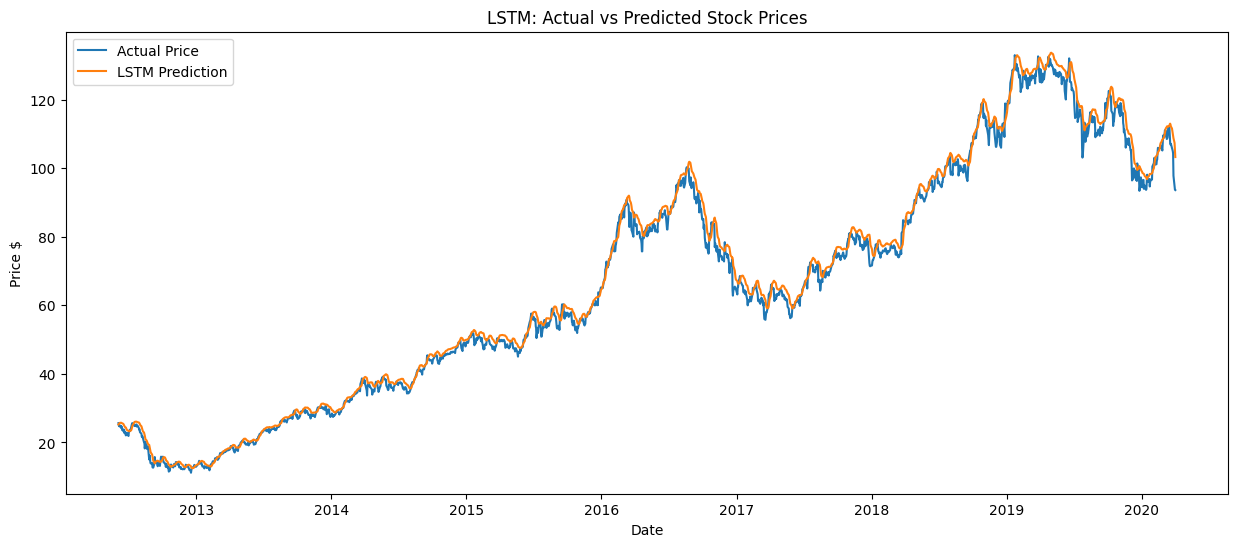

In [21]:
# Inverse transform actual values and predictions back to original price scale
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
lstm_pred_original = scaler.inverse_transform(lstm_pred.reshape(-1, 1))

plt.figure(figsize=(15,6))

# Actual values (original price scale)
plt.plot(df.index[-len(y_test_original):], y_test_original, label="Actual Price")

# LSTM predictions (original price scale)
plt.plot(df.index[-len(lstm_pred_original):], lstm_pred_original, label="LSTM Prediction")

# Labels
plt.title("LSTM: Actual vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price $")

plt.legend()

# Save figure
plt.savefig("lstm_actual_vs_predicted.png", dpi=1000, bbox_inches="tight")

plt.show()

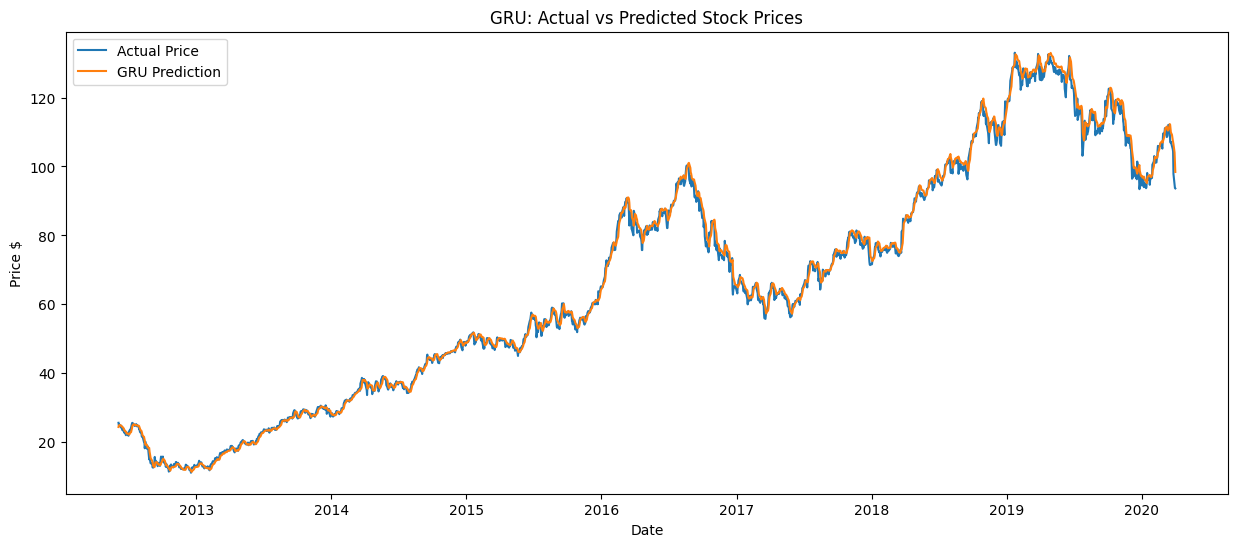

In [22]:
# Inverse transform actual values and GRU predictions back to original price scale
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
gru_pred_original = scaler.inverse_transform(gru_pred.reshape(-1, 1))

plt.figure(figsize=(15,6))

# Actual values (original price scale)
plt.plot(df.index[-len(y_test_original):], y_test_original, label="Actual Price")

# GRU predictions (original price scale)
plt.plot(df.index[-len(gru_pred_original):], gru_pred_original, label="GRU Prediction")

# Labels
plt.title("GRU: Actual vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price $")

plt.legend()

# Save figure
plt.savefig("gru_actual_vs_predicted.png", dpi=1000, bbox_inches="tight")

plt.show()

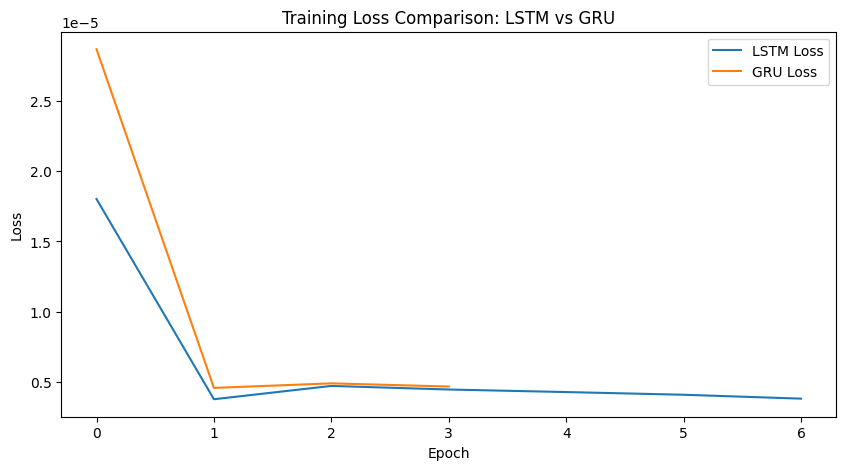

In [29]:
# Plot training loss comparison between LSTM and GRU models
plt.figure(figsize=(10,5))

# LSTM training loss curve
plt.plot(history_lstm.history['loss'], label='LSTM Loss')

# GRU training loss curve
plt.plot(history_gru.history['loss'], label='GRU Loss')

# Add chart title and axis labels
plt.title("Training Loss Comparison: LSTM vs GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Add legend
plt.legend()

# Save the figure before displaying
plt.savefig("lstm_gru_training_loss After Tuning.png", dpi=1000, bbox_inches="tight")

# Display plot
plt.show()

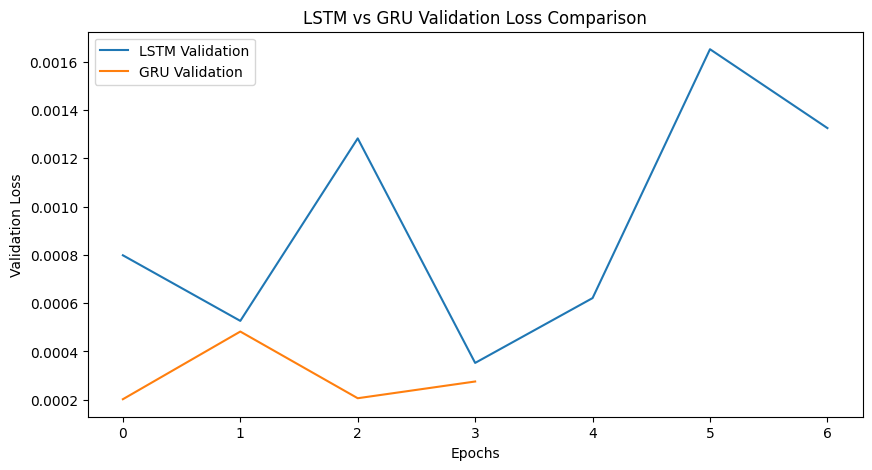

In [30]:
# Plot validation loss comparison between LSTM and GRU models
plt.figure(figsize=(10,5))

# LSTM validation loss curve
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation')

# GRU validation loss curve
plt.plot(history_gru.history['val_loss'], label='GRU Validation')

# Labels and title
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('LSTM vs GRU Validation Loss Comparison')

# Legend
plt.legend()

# Save figure
plt.savefig('lstm_gru_validation_loss After Tuning.png', dpi=300, bbox_inches='tight')

# Show plot
plt.show()

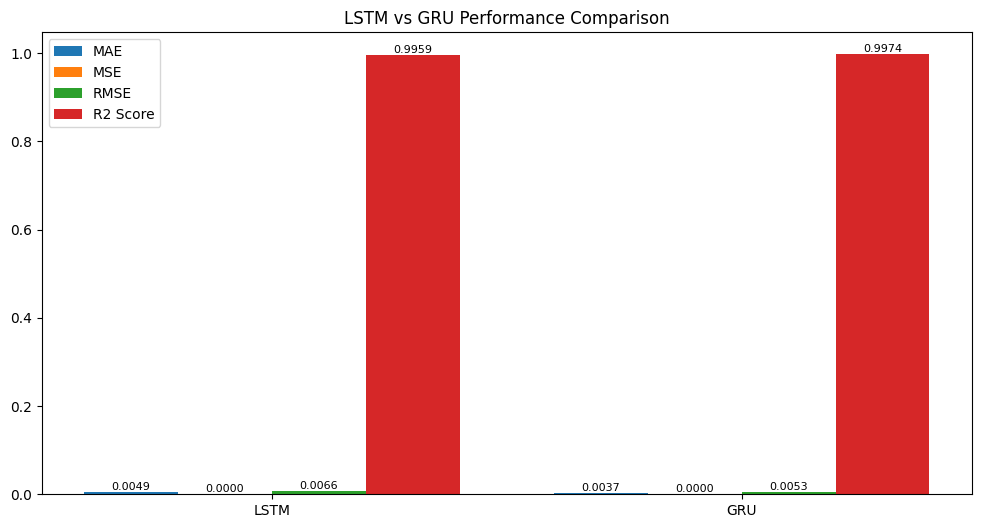

In [32]:
# Extract model names and performance metrics from comparison dataframe
models = comparison1["Model"]
mae = comparison1["MAE"]
mse = comparison1["MSE"]
rmse = comparison1["RMSE"]
r2 = comparison1["R2 Score"]

# Create x-axis positions for grouped bar chart
x = np.arange(len(models))

# Width of each bar group
width = 0.2

# Create figure with defined size
plt.figure(figsize=(12,6))

# Plot MAE bars
bars1 = plt.bar(x - 1.5*width, mae, width, label="MAE")

# Plot MSE bars
bars2 = plt.bar(x - 0.5*width, mse, width, label="MSE")

# Plot RMSE bars
bars3 = plt.bar(x + 0.5*width, rmse, width, label="RMSE")

# Plot R2 Score bars
bars4 = plt.bar(x + 1.5*width, r2, width, label="R2 Score")

# Function to annotate bars with values
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.4f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

# Add annotations to each metric group
add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

# Set x-axis labels as model names
plt.xticks(x, models)

# Add chart title
plt.title("LSTM vs GRU Performance Comparison")

#Save figure before displaying
plt.savefig("LSTM vs GRU Performance Comparison", dpi=1000, bbox_inches="tight")

# Show legend
plt.legend()

# Display plot
plt.show()